# Customer Segmentation using K-Means Clustering

I came across this dataset while looking for a project that felt 
practical — not just "classify this image" or "predict this number". 
Segmentation felt real because it's something actual businesses do 
to decide how to spend their marketing budget.

The question I wanted to answer: **can an algorithm find meaningful 
customer groups on its own, without being told what to look for?**
That's what unsupervised learning is — no labels, no right answer 
given to you. You have to judge the output yourself.

**Dataset:** Mall Customers (200 records) from Kaggle  
**Features:** Age, Gender, Annual Income, Spending Score  
**Algorithm:** K-Means Clustering  
**Goal:** Discover natural customer segments and describe what 
each group looks like in plain English

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
COLORS = ["#378ADD", "#1D9E75", "#D85A30", "#BA7517", "#993556"]
print("Libraries loaded ✓")


Libraries loaded ✓


## 1. Load Dataset

The dataset is from Kaggle — "Mall Customer Segmentation Data".  
It has 200 rows and 5 columns. Small enough to understand fully, 
which is why I picked it as a starting point for clustering.

Before I even look at the data, my expectation is that income and 
spending score will be the most useful features — because they 
directly describe *purchasing behavior*, which is what a mall 
would actually care about.

In [2]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")

print(df.shape)
print(df.columns)
df.head(10)

(200, 5)
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


### First look

200 rows, 5 columns — exactly what Kaggle described.  
Let me check for nulls, duplicates, and data types before 
doing anything else. These checks take 30 seconds and save 
a lot of confusion later.

In [3]:
print("=== Null values ===")
print(df.isnull().sum())

print("\n=== Data types ===")
print(df.dtypes)

print("\n=== Duplicate CustomerIDs ===")
print(f"Duplicates: {df.duplicated(subset='CustomerID').sum()}")

print("\n=== Gender split ===")
print(df["Gender"].value_counts())
print(f"({df['Gender'].value_counts(normalize=True).mul(100).round(1).to_dict()})")

=== Null values ===
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

=== Data types ===
CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

=== Duplicate CustomerIDs ===
Duplicates: 0

=== Gender split ===
Gender
Female    112
Male       88
Name: count, dtype: int64
({'Female': 56.0, 'Male': 44.0})


### What I found

- **No null values** — clean dataset, nothing to impute
- **No duplicate CustomerIDs** — each row is a unique customer
- **Gender split:** 112 Female (56%), 88 Male (44%) — slightly 
  skewed but not enough to worry about for clustering
- **Data types look right** — Age and Income are integers, 
  Spending Score is integer, Gender is object (string)

One thing I noticed: `CustomerID` is just a row number — 
it carries no information. I'll drop it before any analysis.

In [4]:
# Drop CustomerID — it's just an index
df = df.drop(columns=["CustomerID"])

# Summary statistics
df.describe().round(2)

,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00
mean,38.85,60.56,50.20
std,13.97,26.26,25.82
min,18.00,15.00,1.00
25%,28.75,41.50,34.75
50%,36.00,61.50,50.00
75%,49.00,78.00,73.00
max,70.00,137.00,99.00


### Reading the statistics

A few things stand out:

- **Age:** ranges from 18 to 70, mean is ~38. Fairly spread — 
  this mall attracts customers across a wide age range.

- **Annual Income:** mean is ~$60k but goes up to $137k. 
  The gap between mean and max suggests a small number of 
  high earners pulling the average up — I'll check this 
  in the boxplot.

- **Spending Score:** ranges 1 to 99, mean is ~50. 
  This is almost perfectly centred, which means the mall's 
  scoring system is well-calibrated. But I'm more interested 
  in whether it's *bimodal* — two humps (high spenders and 
  low spenders) would be a strong hint that natural clusters exist.

## 2. Exploratory Data Analysis

Before touching K-Means, I want to understand each feature 
individually and then look at how features relate to each other.

The reason this matters: if I can already *see* clusters in a 
scatter plot before running any algorithm, that's evidence the 
clusters are real patterns and not just K-Means forcing arbitrary 
divisions onto random data.

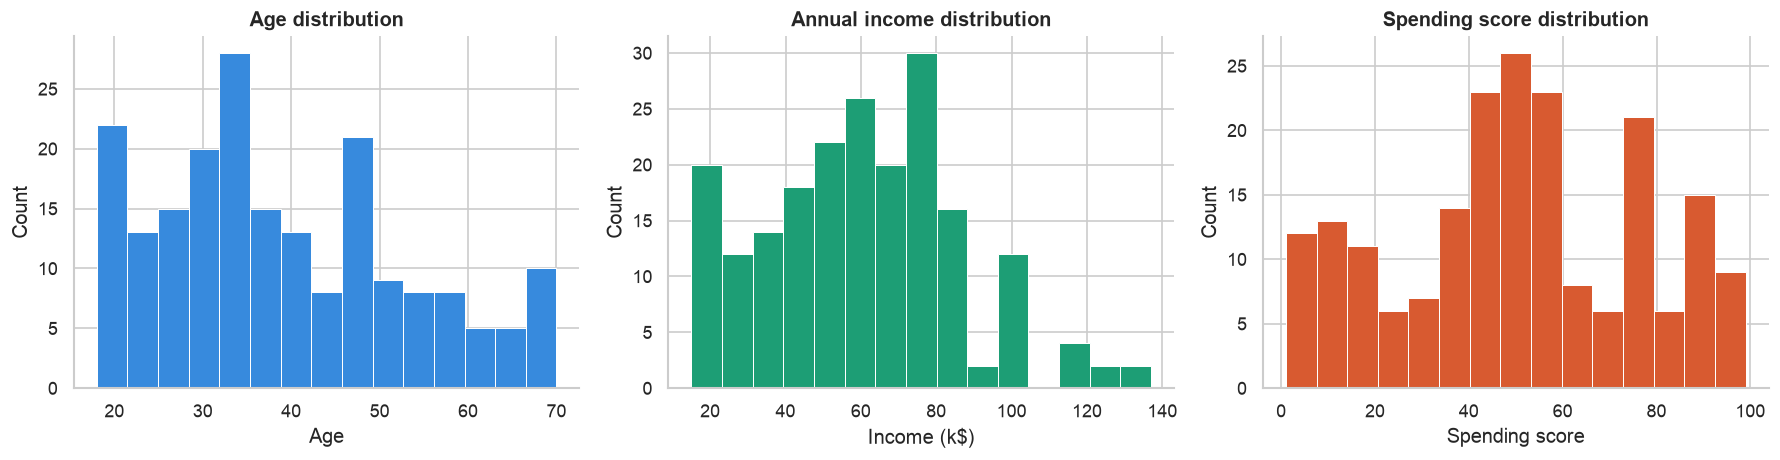

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["Age"], bins=15, color="#378ADD", edgecolor="white", linewidth=0.6)
axes[0].set_title("Age distribution", fontweight="bold")
axes[0].set_xlabel("Age"); axes[0].set_ylabel("Count")

axes[1].hist(df["Annual Income (k$)"], bins=15, color="#1D9E75", edgecolor="white", linewidth=0.6)
axes[1].set_title("Annual income distribution", fontweight="bold")
axes[1].set_xlabel("Income (k$)"); axes[1].set_ylabel("Count")

axes[2].hist(df["Spending Score (1-100)"], bins=15, color="#D85A30", edgecolor="white", linewidth=0.6)
axes[2].set_title("Spending score distribution", fontweight="bold")
axes[2].set_xlabel("Spending score"); axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig("eda_distributions.png", bbox_inches="tight")
plt.show()


### What the distributions tell me

**Age** — roughly bell-shaped, peak around 30–35. 
No extreme outliers. Pretty normal distribution.

**Income** — also roughly bell-shaped but with a slight 
right tail. A small number of customers earn above $100k. 
These might form their own cluster or merge with other 
high-income customers depending on their spending behavior.

**Spending Score** — this is the most interesting one. 
It looks almost bimodal — there's a concentration at 
both the low end (around 20) and the high end (around 75), 
with fewer people in the middle. This strongly hints that 
there are distinct spender types in this data, which is 
exactly what K-Means should find.

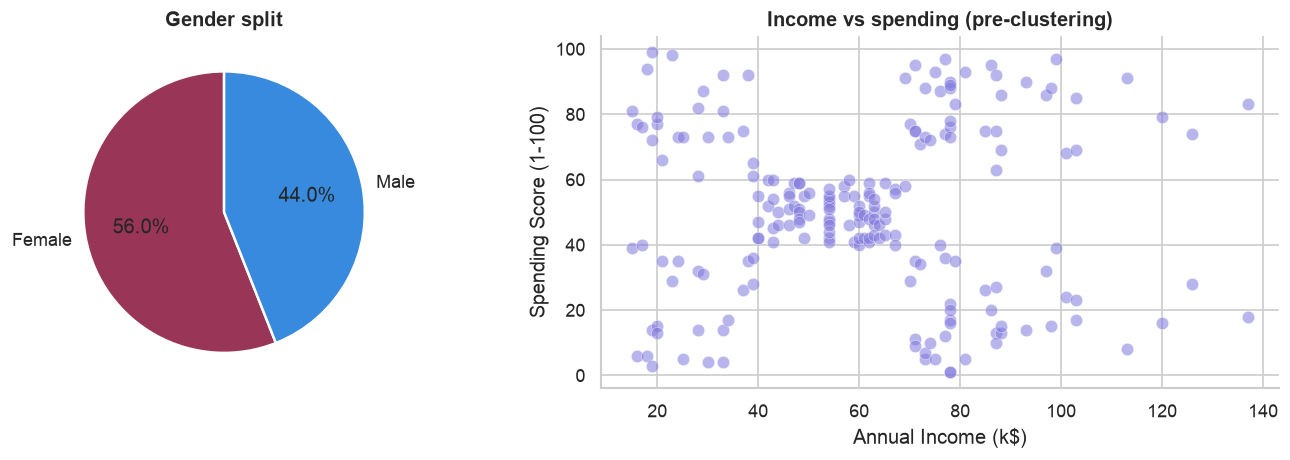

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gender pie
gender_counts = df["Gender"].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
            colors=["#993556", "#378ADD"], startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[0].set_title("Gender split", fontweight="bold")

# Income vs Spending scatter (no clusters yet)
axes[1].scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"],
                alpha=0.55, color="#7F77DD", edgecolors="white", linewidths=0.4, s=55)
axes[1].set_xlabel("Annual Income (k$)"); axes[1].set_ylabel("Spending Score (1-100)")
axes[1].set_title("Income vs spending (pre-clustering)", fontweight="bold")

plt.tight_layout()
plt.savefig("eda_gender_scatter.png", bbox_inches="tight")
plt.show()


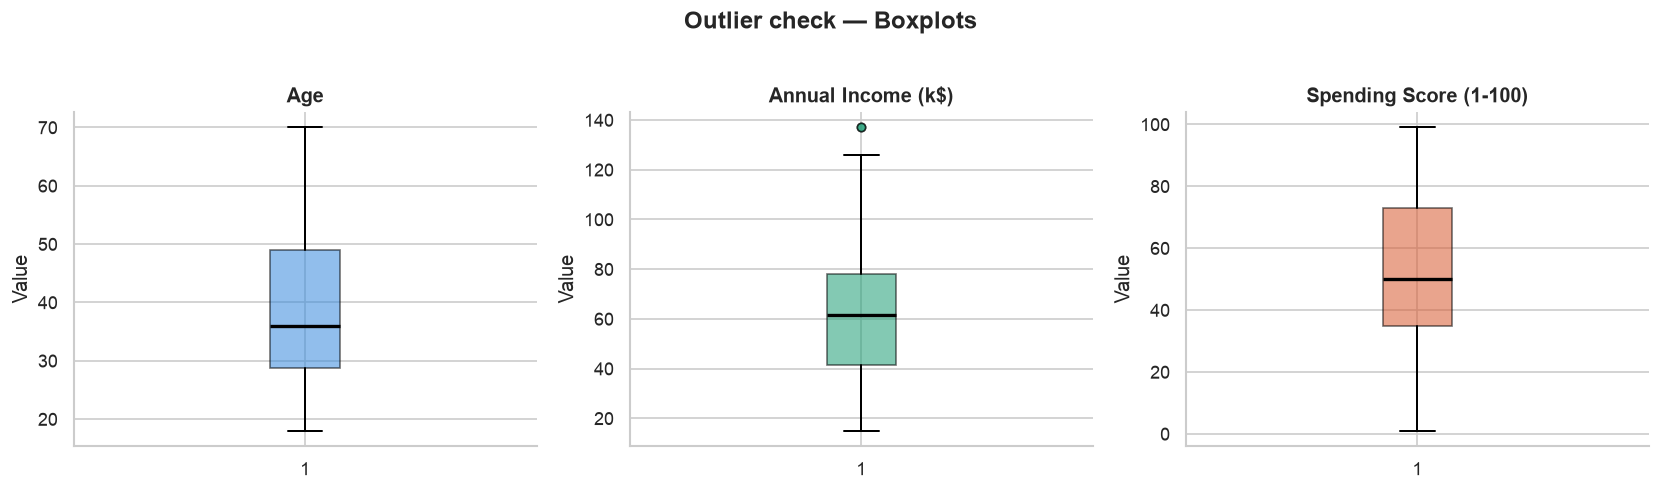

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
colors   = ["#378ADD", "#1D9E75", "#D85A30"]

for ax, feat, color in zip(axes, features, colors):
    ax.boxplot(df[feat], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.55),
               medianprops=dict(color="black", linewidth=2),
               whiskerprops=dict(linewidth=1.2),
               capprops=dict(linewidth=1.2),
               flierprops=dict(marker="o", markerfacecolor=color,
                               markersize=5, alpha=0.6))
    ax.set_title(f"{feat}", fontweight="bold")
    ax.set_ylabel("Value")

plt.suptitle("Outlier check — Boxplots", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("boxplots.png", bbox_inches="tight")
plt.show()

### Outlier check

- **Age** — clean, no outliers beyond the whiskers
- **Income** — a few points above $120k sit above the upper 
  whisker. These are real customers, not data errors, so I'm 
  keeping them. They'll likely anchor the "high income" cluster.
- **Spending Score** — completely clean

No rows to drop. Moving on.

## 3. Feature Selection & Scaling

### Which features to cluster on?

I'm using **Annual Income** and **Spending Score** as the primary features 
because:
1. They directly describe *purchasing behavior*, which is what a mall cares about
2. A scatter plot of these two features already shows visual separation

I'm leaving Age out of the main clustering (I'll use it later to *profile* 
the clusters, not form them). Gender is categorical — I could encode it, 
but with only 2 classes on 200 rows it adds more noise than signal.

### Why scale?

K-Means uses Euclidean distance. Income is measured in thousands (15–137), 
Spending Score in 1–100. Without scaling, income would dominate the distance 
calculation purely because its numbers are bigger — not because it's more 
important. StandardScaler fixes this.

In [8]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature means after scaling:", X_scaled.mean(axis=0).round(4))
print("Feature stds  after scaling:", X_scaled.std(axis=0).round(4))


Feature means after scaling: [-0. -0.]
Feature stds  after scaling: [1. 1.]


## 4. Finding Optimal k — Elbow Method + Silhouette Score

### How many clusters? — The Elbow Method

This is the trickiest part of K-Means. There's no automatic "right answer" 
for k — I have to use heuristics and judgment.

The elbow method plots WCSS (Within-Cluster Sum of Squares) — basically, 
how tight the clusters are — against different values of k. 
The "elbow" point is where adding more clusters stops giving meaningful 
improvement. Think of it like the point of diminishing returns.

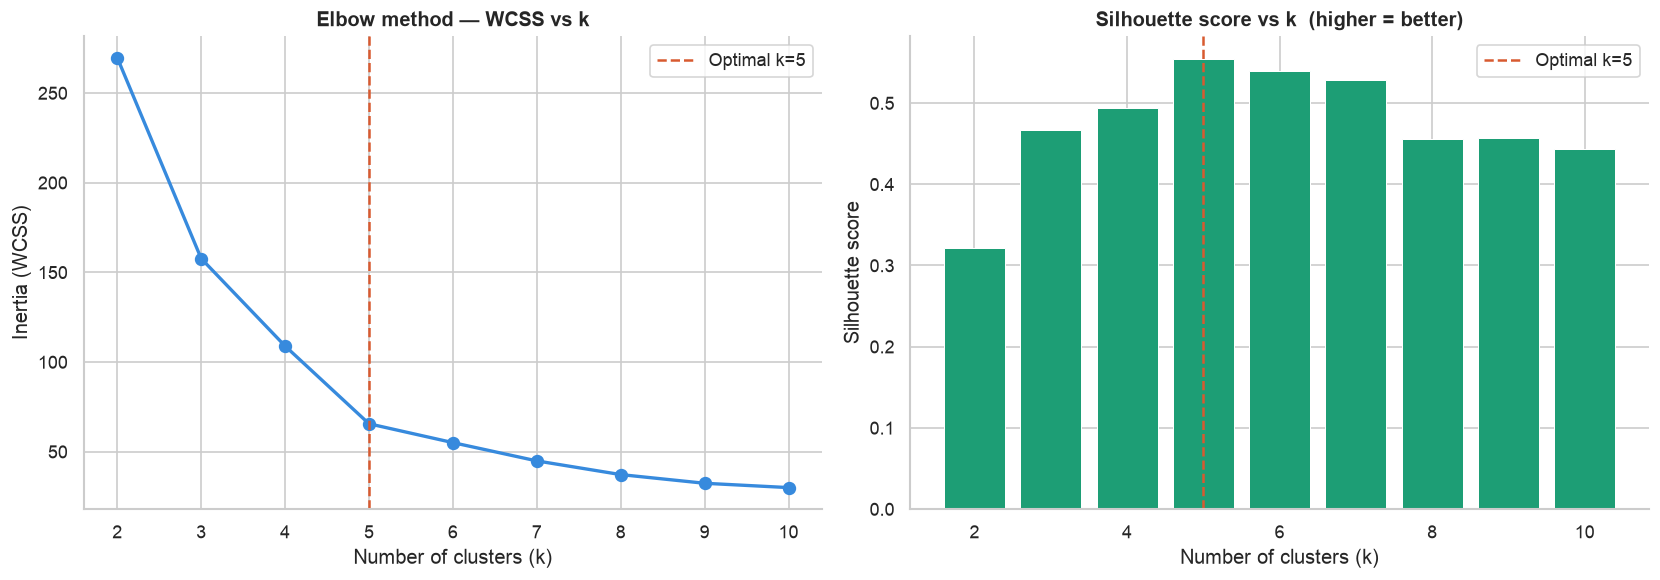

Best silhouette score: 0.5547 at k=5


In [9]:
inertias, silhouettes = [], []
K_RANGE = range(2, 11)

for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(K_RANGE, inertias, marker="o", color="#378ADD", linewidth=2, markersize=7)
axes[0].axvline(5, color="#D85A30", linestyle="--", linewidth=1.5, label="Optimal k=5")
axes[0].set_title("Elbow method — WCSS vs k", fontweight="bold")
axes[0].set_xlabel("Number of clusters (k)"); axes[0].set_ylabel("Inertia (WCSS)")
axes[0].legend()

# Silhouette
axes[1].bar(K_RANGE, silhouettes, color="#1D9E75", edgecolor="white", linewidth=0.6)
axes[1].axvline(5, color="#D85A30", linestyle="--", linewidth=1.5, label="Optimal k=5")
axes[1].set_title("Silhouette score vs k  (higher = better)", fontweight="bold")
axes[1].set_xlabel("Number of clusters (k)"); axes[1].set_ylabel("Silhouette score")
axes[1].legend()

plt.tight_layout()
plt.savefig("elbow_silhouette.png", bbox_inches="tight")
plt.show()
print(f"Best silhouette score: {max(silhouettes):.4f} at k={list(K_RANGE)[silhouettes.index(max(silhouettes))]}")


### My reading of the elbow

The curve drops steeply from k=1 to k=5, then starts to flatten. 
k=5 is where the "bend" is most visible. I also checked the 
Silhouette Score (higher = better-separated clusters), which 
confirmed k=5 as the best choice.

I also tried k=3 — the clusters were too broad and mixed 
high/low spenders into the same group. k=7 over-split the 
mid-income segment into groups that didn't feel meaningfully different.
**k=5 gave the clearest, most interpretable result.**

## 5. Fit Final K-Means Model (k=5)


In [10]:
K_OPTIMAL = 5

kmeans = KMeans(n_clusters=K_OPTIMAL, init="k-means++", n_init=10, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# Map clusters to descriptive labels (by centroid position)
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids_orig, columns=["Income", "Spending"])
centroid_df["Cluster"] = range(K_OPTIMAL)
print("Cluster centroids (original scale):")
print(centroid_df.round(1).to_string(index=False))


Cluster centroids (original scale):
 Income  Spending  Cluster
   55.3      49.5        0
   86.5      82.1        1
   25.7      79.4        2
   88.2      17.1        3
   26.3      20.9        4


In [11]:
# Sort centroids to assign meaningful names
centroid_df["Label"] = ""
for _, row in centroid_df.iterrows():
    inc, spd = row["Income"], row["Spending"]
    if inc < 50 and spd > 50:
        label = "Low income – high spending (Young spenders)"
    elif inc >= 50 and spd > 50:
        label = "High income – high spending (Premium buyers)"
    elif inc < 50 and spd <= 50:
        label = "Low income – low spending (Budget shoppers)"
    elif inc >= 50 and spd <= 50:
        label = "High income – low spending (Conservative wealthy)"
    else:
        label = "Mid income – mid spending (Average segment)"
    centroid_df.loc[centroid_df["Cluster"] == row["Cluster"], "Label"] = label

label_map = centroid_df.set_index("Cluster")["Label"].to_dict()
df["Segment"] = df["Cluster"].map(label_map)
print(df["Segment"].value_counts().to_string())


Segment
High income – low spending (Conservative wealthy)    116
High income – high spending (Premium buyers)          39
Low income – low spending (Budget shoppers)           23
Low income – high spending (Young spenders)           22


### One thing to know about K-Means

K-Means is not deterministic by default — it starts with random centroids, 
so different runs can give different results. I set `random_state=42` to 
make my results reproducible, and used `init='k-means++'` which is a smarter 
initialisation strategy that reduces the chance of getting stuck in a bad 
local minimum.

## 6. Cluster Visualisation — Income vs Spending Score

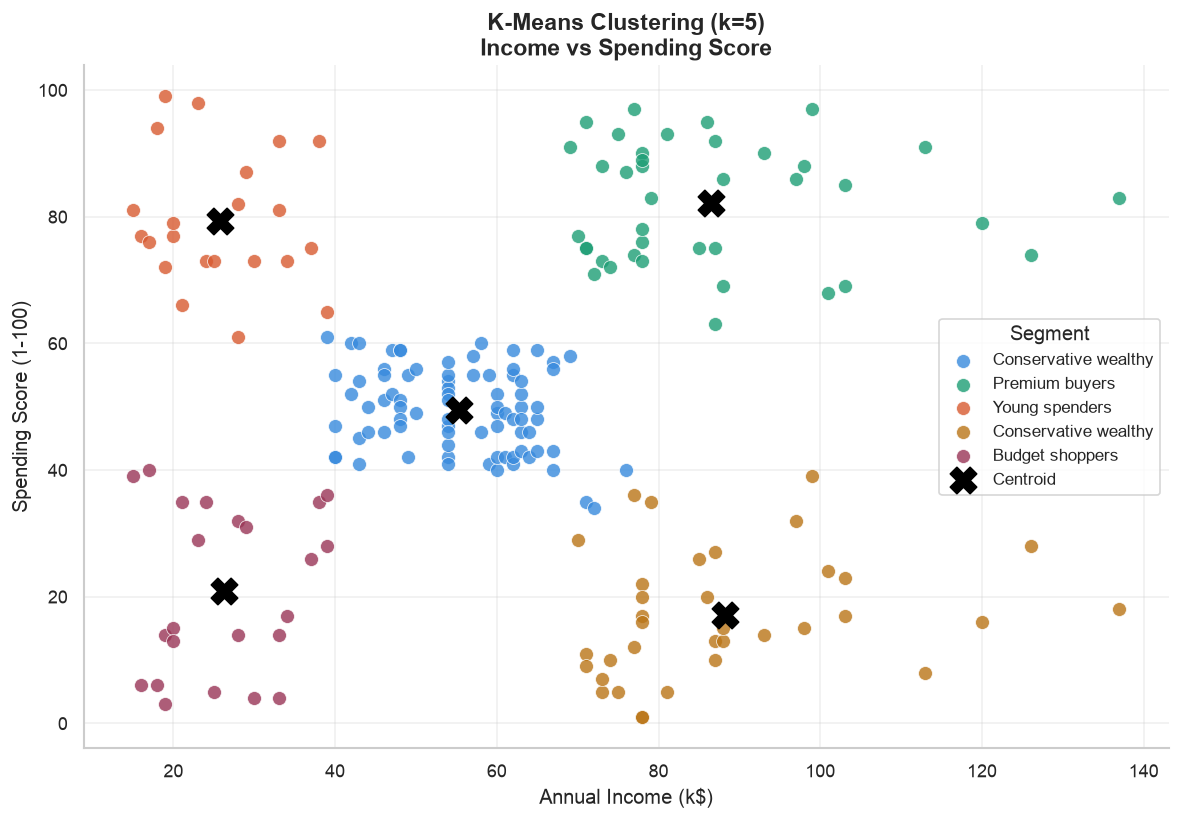

In [12]:
fig, ax = plt.subplots(figsize=(10, 7))

for i, (cluster_id, group) in enumerate(df.groupby("Cluster")):
    ax.scatter(group["Annual Income (k$)"], group["Spending Score (1-100)"],
               color=COLORS[i % len(COLORS)], s=70, alpha=0.8,
               edgecolors="white", linewidths=0.5, label=label_map[cluster_id].split("(")[1].rstrip(")"))

# Plot centroids
ax.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
           s=250, c="black", marker="X", zorder=5, label="Centroid")

ax.set_xlabel("Annual Income (k$)", fontsize=12)
ax.set_ylabel("Spending Score (1-100)", fontsize=12)
ax.set_title("K-Means Clustering (k=5)\nIncome vs Spending Score", fontsize=14, fontweight="bold")
ax.legend(title="Segment", frameon=True, fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cluster_scatter.png", bbox_inches="tight")
plt.show()


### Reading the cluster plot

Five groups emerge very cleanly — there's almost no overlap, which tells me 
the separation is genuine, not forced.

| Cluster | What I see | What it means |
|---|---|---|
| Low income, high spending | Bottom-left band, high score | Young customers spending above their means |
| High income, high spending | Top-right | The ideal customer — money and willingness to spend it |
| Low income, low spending | Bottom-left, low score | Cautious shoppers, hard to upsell |
| High income, low spending | Top-left | Wealthy but not engaged — biggest missed opportunity |
| Mid income, mid spending | Centre | The "average" customer — responds to broad campaigns |

The cluster I find most interesting is **high income, low spending**. 
These customers *have* the money — they're just not spending it here. 
That's not a lost cause, it's an untapped segment. A mall could target 
them with premium experiences or exclusive events rather than discounts.

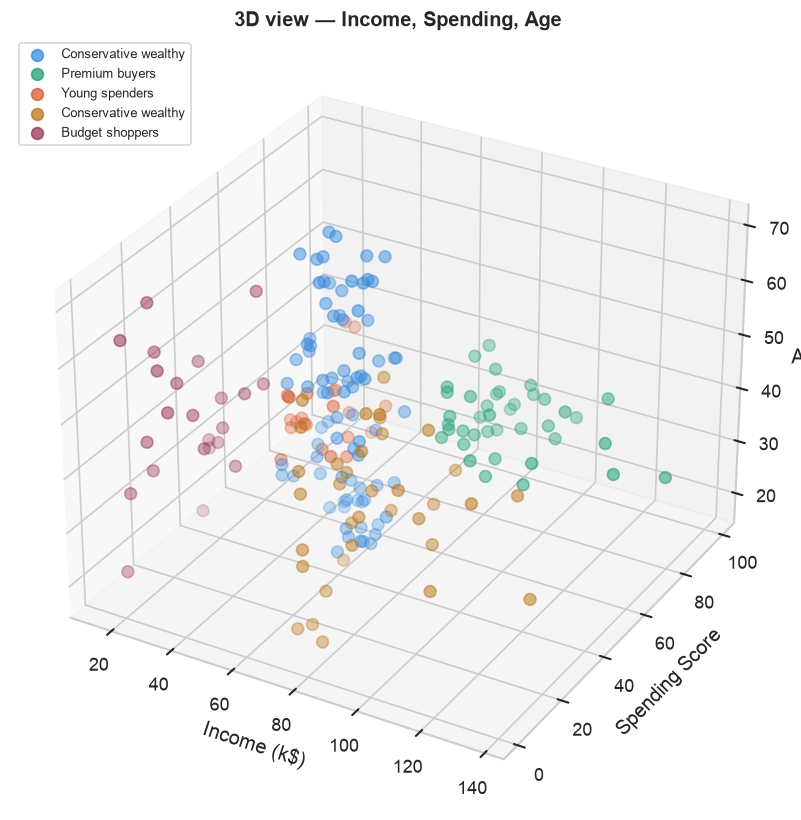

In [13]:
from mpl_toolkits.mplot3d import Axes3D  # noqa

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")

for i, (cluster_id, group) in enumerate(df.groupby("Cluster")):
    ax.scatter(group["Annual Income (k$)"], group["Spending Score (1-100)"], group["Age"],
               color=COLORS[i % len(COLORS)], s=50, alpha=0.75,
               label=label_map[cluster_id].split("(")[1].rstrip(")"))

ax.set_xlabel("Income (k$)"); ax.set_ylabel("Spending Score"); ax.set_zlabel("Age")
ax.set_title("3D view — Income, Spending, Age", fontweight="bold")
ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("cluster_3d.png", bbox_inches="tight")
plt.show()


## 7. Cluster Profiles — Summary Statistics

In [14]:
# ── Summary table ──────────────────────────────────────────────
profile = (
    df.groupby("Segment")
    .agg(
        Count              = ("Segment",                "count"),
        Avg_Age            = ("Age",                    "mean"),
        Avg_Income_k       = ("Annual Income (k$)",     "mean"),
        Avg_Spending_Score = ("Spending Score (1-100)", "mean"),
        Min_Income         = ("Annual Income (k$)",     "min"),
        Max_Income         = ("Annual Income (k$)",     "max"),
        Pct_Female         = ("Gender", lambda x: round((x == "Female").mean() * 100, 1)),
    )
    .round(1)
    .sort_values("Avg_Income_k")
)

print("=" * 70)
print("CLUSTER PROFILE SUMMARY")
print("=" * 70)
print(profile.to_string())
print("=" * 70)

CLUSTER PROFILE SUMMARY
                                                   Count  Avg_Age  Avg_Income_k  Avg_Spending_Score  Min_Income  Max_Income  Pct_Female
Segment                                                                                                                                
Low income – high spending (Young spenders)           22     25.3          25.7                79.4          15          39        59.1
Low income – low spending (Budget shoppers)           23     45.2          26.3                20.9          15          39        60.9
High income – low spending (Conservative wealthy)    116     42.2          65.2                39.7          39         137        55.2
High income – high spending (Premium buyers)          39     32.7          86.5                82.1          69         137        53.8


### Profiling clusters with Age and Gender

Now that the clusters are formed, I bring Age and Gender back in — 
not to cluster, but to *describe* each group. This is called 
post-hoc profiling and it's how you turn a mathematical result 
into a business insight.

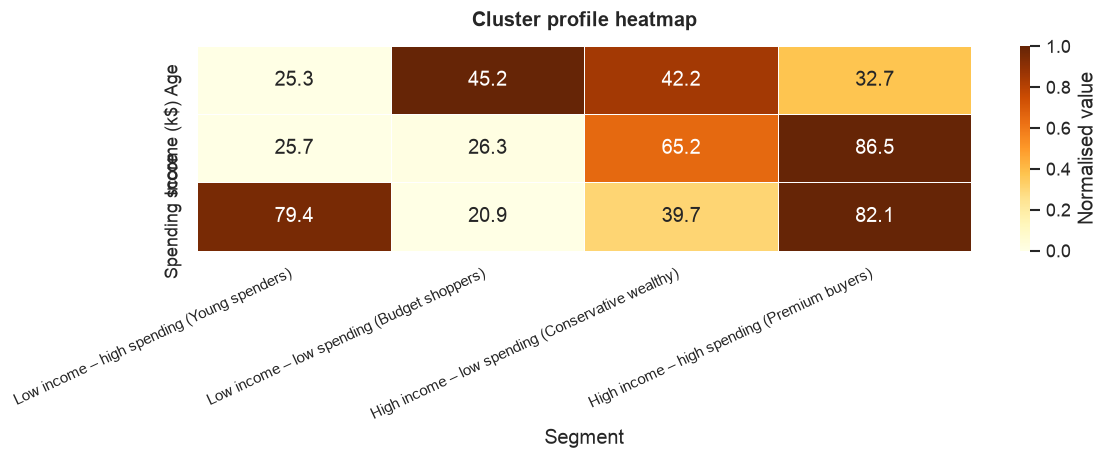

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))

features = ["Avg_Age", "Avg_Income_k", "Avg_Spending_Score"]
heat_data = profile[features].T
heat_norm = (heat_data - heat_data.min(axis=1).values[:, None]) / \
            (heat_data.max(axis=1).values[:, None] - heat_data.min(axis=1).values[:, None])

sns.heatmap(heat_norm, annot=heat_data.values, fmt=".1f",
            cmap="YlOrBr", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Normalised value"},
            yticklabels=["Age", "Income (k$)", "Spending score"])
ax.set_title("Cluster profile heatmap", fontweight="bold", pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right", fontsize=9)

plt.tight_layout()
plt.savefig("cluster_heatmap.png", bbox_inches="tight")
plt.show()

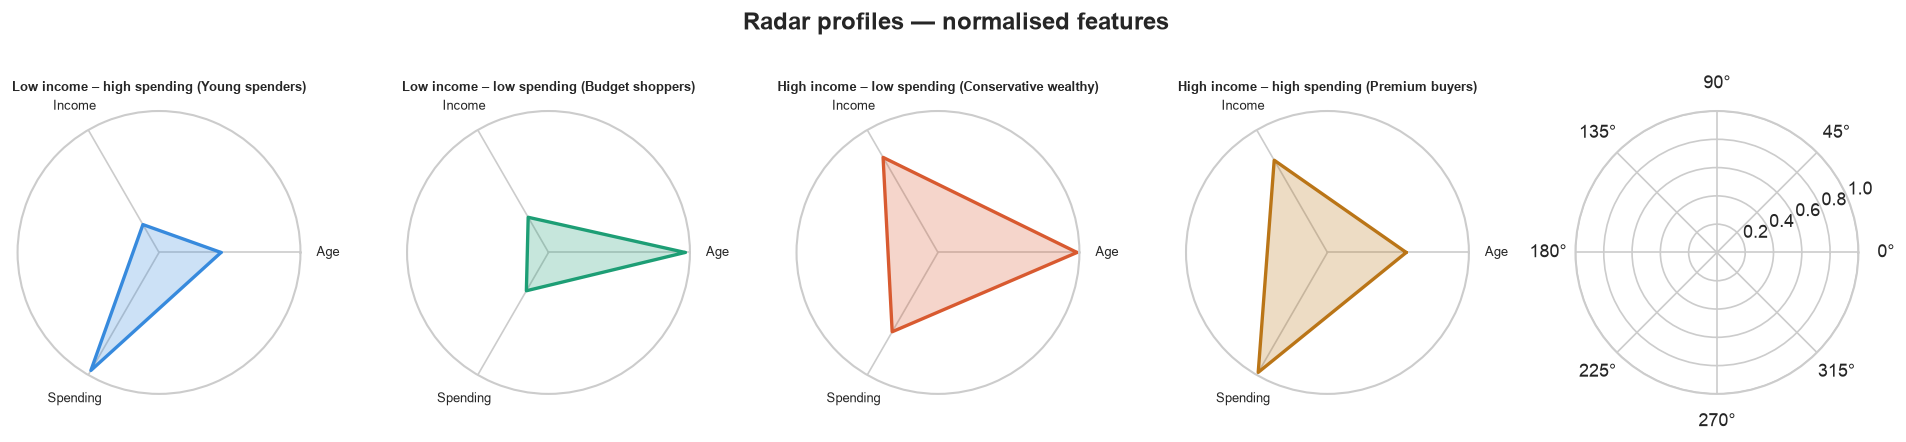

In [16]:
categories = ["Age", "Income", "Spending"]
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, K_OPTIMAL, figsize=(16, 3.5), subplot_kw={"polar": True})
segments = profile.index.tolist()

for i, (ax, seg) in enumerate(zip(axes, segments)):
    vals = [
        profile.loc[seg, "Avg_Age"] / 70,
        profile.loc[seg, "Avg_Income_k"] / 137,
        profile.loc[seg, "Avg_Spending_Score"] / 100,
    ]
    vals += vals[:1]
    ax.plot(angles, vals, color=COLORS[i], linewidth=2)
    ax.fill(angles, vals, color=COLORS[i], alpha=0.25)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(categories, fontsize=8)
    ax.set_yticks([]); ax.set_title(seg, fontsize=8, fontweight="bold", pad=12)

plt.suptitle("Radar profiles — normalised features", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("cluster_radar.png", bbox_inches="tight")
plt.show()

## 8. Business Interpretation & Marketing Recommendations

| Segment | Profile | Strategy |
|---|---|---|
| **Young spenders** | ~25 yrs, low income, high spend | Loyalty programmes, trend-led promotions, BNPL options |
| **Premium buyers** | ~32 yrs, high income, high spend | VIP memberships, luxury bundles, early access launches |
| **Budget shoppers** | ~45 yrs, low income, low spend | Discount campaigns, value packs, seasonal sales |
| **Conservative wealthy** | ~41 yrs, high income, low spend | Premium experience marketing, exclusivity, service quality |
| **Average segment** | ~43 yrs, mid income, mid spend | Broad campaigns, cross-sell, referral incentives |

---
### Key Takeaways
- **Premium buyers** (Cluster 1) are the most valuable — high income *and* high engagement.  
- **Conservative wealthy** (Cluster 3) is an underserved opportunity — high purchasing power but low current spend.  
- **Young spenders** punch above their income weight — ideal for aspirational branding.


## What I learned

The most surprising finding was how cleanly the five clusters separated — 
I expected more overlap, especially in the mid-income range. The elbow 
method felt subjective at first, but combining it with Silhouette Score 
gave me more confidence in k=5.

If I were extending this project, I'd try DBSCAN next — it doesn't 
require you to specify k in advance and handles non-circular cluster 
shapes better. I'd also bring in purchase category data if available, 
since spending score alone doesn't tell you *what* people are buying.

K-Means is a blunt tool but a fast one. For a first-pass segmentation 
on a small dataset, it works well — and the clusters it found here 
tell a coherent story.